# Comparative Analysis: Misfit Function vs. Deep Learning (MLP)
This notebook compares the predictive performance of two approaches for determining AGNR impurity concentration from transmission spectra:
1. **Physical Misfit Function**: Predicts concentration by finding the minimum squared difference against a database of reference spectra.
2. **Deep Learning PINN (ConductanceMLP)**: Predicts concentration directly from normalized spectra.



In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
class ConductanceMLP(nn.Module):
    """Multi-Layer Perceptron for concentration prediction."""
    def __init__(self, input_length: int = 200, hidden_dims: list = None,
                 dropout: float = 0.2, noise_std: float = 0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 128, 64, 32]
        self.noise_std = noise_std
        layers = []
        in_dim = input_length
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.LayerNorm(h_dim))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        self.mlp = nn.Sequential(*layers)
        self.regressor = nn.Linear(in_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training and self.noise_std > 0:
            noise = 1.0 + torch.randn_like(x) * self.noise_std
            x = x * noise
        x = self.mlp(x)
        return self.regressor(x)


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

save_path = 'pinn_agnr_curvature.pt'
try:
    checkpoint = torch.load(save_path, map_location=device, weights_only=True)
except TypeError:
    checkpoint = torch.load(save_path, map_location=device)

args = checkpoint.get('args', {})
spectrum_len = args.get('spectrum_len', 200)

model = ConductanceMLP(input_length=spectrum_len).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully!")


Using device: cpu
Model loaded successfully!


In [4]:
project_root = Path("../../")
data_dir = project_root / "data" / "raw" / "transmission_results"
test_dir = project_root / "data" / "test" / "transmission_results"

# Load pristine
pristine_path = data_dir / "pristine.npy"
pristine = np.load(str(pristine_path))[:spectrum_len].astype(np.float32)

# Build reference spectra for misfit (average of 100 configs)
conc_range = np.arange(3, 45, 2)
n_sample_configs = 100
ref_list = []

print("Building reference spectra...")
for con in conc_range:
    acc = []
    for cfg in range(n_sample_configs):
        fpath = data_dir / f"7_agnr_conc{int(con)}_cfg{cfg}.npy"
        if fpath.exists():
            spec = np.load(str(fpath)).astype(np.float32)[:spectrum_len]
            spec = np.clip(spec, 0, pristine)
            acc.append(spec)
    if len(acc) > 0:
        avg_spec = np.mean(acc, axis=0)
        # Normalize
        ref_normalised = avg_spec / (pristine + 1e-8)
        ref_list.append(ref_normalised)

ref_spectra = np.array(ref_list)
print(f"Loaded {len(ref_list)} reference spectra for concentrations: {conc_range}")


Building reference spectra...
Loaded 21 reference spectra for concentrations: [ 3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43]


In [5]:
def predict_misfit(test_spectrum_norm, ref_spectra, concentrations, spectrum_start=20, spectrum_end=150):
    # Crop to region of interest (same as training CurvatureMisfit)
    test_crop = test_spectrum_norm[spectrum_start:spectrum_end]
    ref_crop = ref_spectra[:, spectrum_start:spectrum_end]
    pristine_crop = pristine[spectrum_start:spectrum_end]
    
    # Un-normalize
    test_unnorm = test_crop * pristine_crop
    ref_unnorm = ref_crop * pristine_crop
    
    # Clip
    test_unnorm = np.clip(test_unnorm, 0.0, pristine_crop)
    
    # Misfit calculation: squared difference
    diff = test_unnorm[None, :] - ref_unnorm
    mis = np.sum(diff ** 2, axis=1) / 150.0
    
    # Argmin gives the predicted concentration index
    min_idx = np.argmin(mis)
    return concentrations[min_idx], mis


In [6]:
test_files = glob.glob(str(test_dir / "*.npy"))
print(f"Found {len(test_files)} test files.")

true_concs = []
dl_preds = []
misfit_preds = []

for fpath in test_files:
    # Parse true concentration from filename: 7_agnr_conc{C}_cfg{C}_test.npy
    filename = os.path.basename(fpath)
    conc_part = filename.split('_conc')[1].split('_')[0]
    true_c = float(conc_part)
    true_concs.append(true_c)
    
    # Load and preprocess
    spec = np.load(fpath).astype(np.float32)[:spectrum_len]
    spec = np.clip(spec, 0, pristine)
    spec_norm = spec / (pristine + 1e-8)
    
    # DL Predict
    with torch.no_grad():
        x = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0).to(device)
        dl_pred = model(x).item()
        dl_preds.append(dl_pred)
        
    # Misfit Predict
    misfit_pred, _ = predict_misfit(spec_norm, ref_spectra, conc_range)
    misfit_preds.append(misfit_pred)

true_concs = np.array(true_concs)
dl_preds = np.array(dl_preds)
misfit_preds = np.array(misfit_preds)

dl_mae = np.mean(np.abs(true_concs - dl_preds))
misfit_mae = np.mean(np.abs(true_concs - misfit_preds))

dl_rmse = np.sqrt(np.mean((true_concs - dl_preds)**2))
misfit_rmse = np.sqrt(np.mean((true_concs - misfit_preds)**2))

print(f"Deep Learning - MAE: {dl_mae:.2f} | RMSE: {dl_rmse:.2f}")
print(f"Misfit Method - MAE: {misfit_mae:.2f} | RMSE: {misfit_rmse:.2f}")


Found 2100 test files.
Deep Learning - MAE: 1.17 | RMSE: 1.56
Misfit Method - MAE: 1.89 | RMSE: 3.11


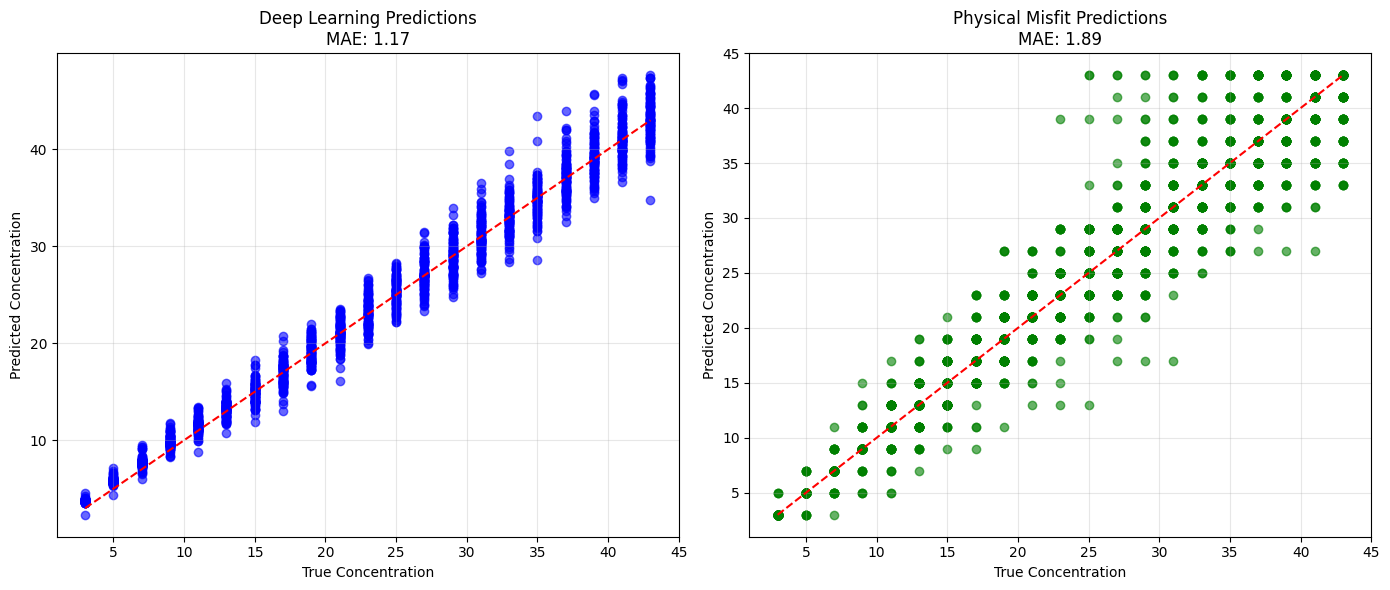

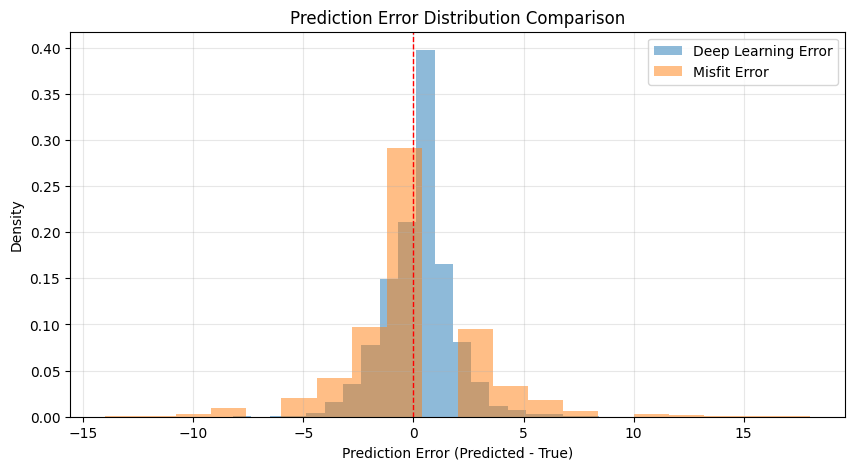

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot DL
axes[0].scatter(true_concs, dl_preds, alpha=0.6, color='blue')
axes[0].plot([min(true_concs), max(true_concs)], [min(true_concs), max(true_concs)], 'r--')
axes[0].set_title(f'Deep Learning Predictions\nMAE: {dl_mae:.2f}')
axes[0].set_xlabel('True Concentration')
axes[0].set_ylabel('Predicted Concentration')
axes[0].grid(True, alpha=0.3)

# Plot Misfit
axes[1].scatter(true_concs, misfit_preds, alpha=0.6, color='green')
axes[1].plot([min(true_concs), max(true_concs)], [min(true_concs), max(true_concs)], 'r--')
axes[1].set_title(f'Physical Misfit Predictions\nMAE: {misfit_mae:.2f}')
axes[1].set_xlabel('True Concentration')
axes[1].set_ylabel('Predicted Concentration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error distribution
plt.figure(figsize=(10, 5))
plt.hist((dl_preds - true_concs), bins=20, alpha=0.5, label='Deep Learning Error', density=True)
plt.hist((misfit_preds - true_concs), bins=20, alpha=0.5, label='Misfit Error', density=True)
plt.axvline(0, color='r', linestyle='dashed', linewidth=1)
plt.xlabel('Prediction Error (Predicted - True)')
plt.ylabel('Density')
plt.title('Prediction Error Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
